# Introducción a MLOps (Notebook 01)

En este notebook vas a recorrer un flujo completo (y reproducible) de *machine learning* para **clasificación binaria** usando *scikit-learn*:

- Generación de datos sintéticos (con valores faltantes para simular “datos reales”).
- EDA mínimo para entender tipos de variables y calidad del dataset.
- Feature engineering sencillo.
- Split de train/test.
- **Pipeline** de preprocesamiento + modelo (evita *data leakage*).
- Evaluación con métricas: *accuracy*, *precision*, *recall*, *F1*, ROC-AUC, matriz de confusión y efectos del **umbral** (*threshold*).

Objetivo: no “ganar” el mejor score (los datos son sintéticos), sino practicar buenas prácticas y entender qué significa la salida del modelo.
__________________________________

## ¿Qué es *data leakage*? (explicación fácil)

**Data leakage** (fuga de información) pasa cuando el modelo “hace trampa” sin querer, porque en entrenamiento ve información que **no debería ver**.

Piensa en esto:

- En `train` el modelo *aprende*.
- En `test` el modelo debe comportarse como si fueran **datos nuevos**.

Hay *leakage* si (por accidente) usas datos del `test` para preparar el `train`.

### Ejemplo muy común
Si calculas la **mediana** para imputar valores faltantes usando *todo el dataset* (train + test), entonces el modelo está usando información del test.

### ¿Por qué el `Pipeline` ayuda?
Porque el flujo correcto es:

1. Separar `train/test`
2. Hacer `pipeline.fit(X_train, y_train)` → aquí el pipeline aprende (medianas, escalado, one-hot) **solo con train**
3. Hacer `pipeline.predict(X_test)` → aquí solo aplica las mismas reglas al test

Resultado: la evaluación es más realista (más parecida a producción).

Ejemplo:
Supongamos un dataset con una feature a la cual le hacen falta valores en algunos registros.

- Calculas la mediana solo con X_train.
- Rellenas X_train con esa mediana.
- Rellenas X_test con esa misma mediana (la del train).

In [1]:
%load_ext autoreload
%reload_ext autoreload

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from generate_data import UserGenerator

In [3]:
generator_data = UserGenerator(seed=42, n_samples=10000)
df = generator_data.create_dataset()

df.head()

Generando datos sintéticos de usuarios para targeting de promociones...
✅ Agregados 493 valores nulos en 'age_group' (5.0%)
✅ Agregados 298 valores nulos en 'location' (3.0%)
✅ Agregados 181 valores nulos en 'device_type' (2.0%)
✅ Agregados 106 valores nulos en 'subscription_type' (1.0%)
✅ Agregados 777 valores nulos en 'avg_order_value' (8.0%)
✅ Agregados 1474 valores nulos en 'last_purchase_days' (15.0%)
✅ Agregados 999 valores nulos en 'time_on_site_minutes' (10.0%)
✅ Agregados 954 valores nulos en 'pages_per_session' (10.0%)
✅ Agregados 1221 valores nulos en 'cart_abandonment_rate' (12.0%)
✅ Agregados 800 valores nulos en 'purchase_frequency' (8.0%)


,user_id,age_group,location,device_type,subscription_type,days_since_registration,total_purchases,avg_order_value,last_purchase_days,sessions_last_30_days,time_on_site_minutes,pages_per_session,cart_abandonment_rate,purchase_frequency,dar_promocion
0,USER-000001,18-25,Mendoza,Mobile,Free,38,6,341.58,139.0,2,71.3,NaN,0.075,4.74,1
1,USER-000002,26-35,Buenos Aires,Mobile,Basic,246,34,215.56,114.0,18,34.1,17.5,0.607,4.15,0
2,USER-000003,36-45,Buenos Aires,Mobile,Enterprise,284,21,60.08,97.0,3,43.7,7.5,0.212,2.22,1
3,USER-000004,36-45,Cordoba,Tablet,Free,343,35,153.66,160.0,19,106.4,7.9,0.154,3.06,0
4,USER-000005,18-25,Buenos Aires,Mobile,Free,330,14,434.58,97.0,8,55.0,16.8,0.130,1.27,1


## 1) EDA rápido: entender los datos

En esta sección buscamos:

- Tipos de variables:
  - **Categóricas** (texto / `object`): requieren codificación (por ejemplo One-Hot).
  - **Numéricas** (`int`, `float`): suelen requerir imputación y, para algunos modelos, escalado.
- Calidad del dataset:
  - Porcentaje de valores faltantes (`NaN`).
  - Rangos de valores y posibles outliers.

Nota MLOps: la imputación/transformaciones se deben hacer **dentro del pipeline** para evitar *data leakage* (contaminar el entrenamiento con información del test).

In [4]:
df.shape

(10000, 15)

<Axes: >

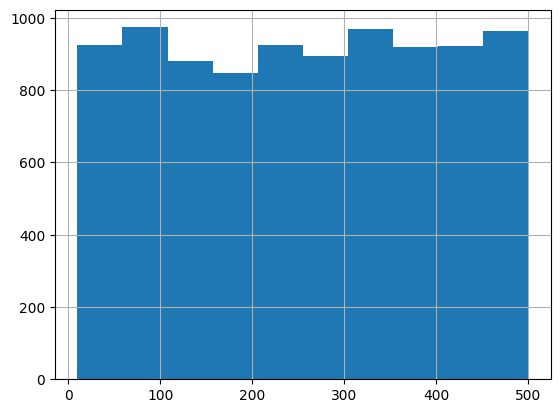

In [5]:
df.avg_order_value.hist()

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   user_id                  10000 non-null  str    
 1   age_group                9507 non-null   str    
 2   location                 9702 non-null   str    
 3   device_type              9819 non-null   str    
 4   subscription_type        9894 non-null   str    
 5   days_since_registration  10000 non-null  int64  
 6   total_purchases          10000 non-null  int64  
 7   avg_order_value          9223 non-null   float64
 8   last_purchase_days       8526 non-null   float64
 9   sessions_last_30_days    10000 non-null  int64  
 10  time_on_site_minutes     9001 non-null   float64
 11  pages_per_session        9046 non-null   float64
 12  cart_abandonment_rate    8779 non-null   float64
 13  purchase_frequency       9200 non-null   float64
 14  dar_promocion            10000 non

In [7]:
df.describe()

,days_since_registration,total_purchases,avg_order_value,last_purchase_days,sessions_last_30_days,time_on_site_minutes,pages_per_session,cart_abandonment_rate,purchase_frequency,dar_promocion
count,10000.000000,10000.000000,9223.000000,8526.000000,10000.000000,9001.000000,9046.000000,8779.000000,9200.000000,10000.000000
mean,179.228600,24.765700,256.321722,112.451677,15.063300,60.302922,10.453117,0.402694,7.294158,0.499500
std,105.853531,14.769313,142.446654,150.410931,8.958891,34.274278,5.485549,0.231219,9.086703,0.500025
min,0.000000,0.000000,10.020000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,87.000000,12.000000,130.060000,45.000000,7.000000,30.800000,5.700000,0.202500,2.000000,0.000000
50%,178.000000,25.000000,258.060000,93.000000,15.000000,59.300000,10.400000,0.404000,4.100000,0.000000
75%,271.000000,38.000000,380.150000,139.000000,23.000000,90.100000,15.200000,0.605000,8.140000,1.000000
max,365.000000,50.000000,499.950000,999.000000,30.000000,120.000000,20.000000,0.800000,50.000000,1.000000


In [8]:
# Elimino la columna user_id dado que no aporta informacion relevante para el modelo

df.drop(columns=['user_id'], inplace=True)

print("Columnas actuales en el DataFrame:")
print(df.columns)

Columnas actuales en el DataFrame:
Index(['age_group', 'location', 'device_type', 'subscription_type',
       'days_since_registration', 'total_purchases', 'avg_order_value',
       'last_purchase_days', 'sessions_last_30_days', 'time_on_site_minutes',
       'pages_per_session', 'cart_abandonment_rate', 'purchase_frequency',
       'dar_promocion'],
      dtype='str')


In [9]:
df.shape

(10000, 14)

In [10]:
df.describe()

,days_since_registration,total_purchases,avg_order_value,last_purchase_days,sessions_last_30_days,time_on_site_minutes,pages_per_session,cart_abandonment_rate,purchase_frequency,dar_promocion
count,10000.000000,10000.000000,9223.000000,8526.000000,10000.000000,9001.000000,9046.000000,8779.000000,9200.000000,10000.000000
mean,179.228600,24.765700,256.321722,112.451677,15.063300,60.302922,10.453117,0.402694,7.294158,0.499500
std,105.853531,14.769313,142.446654,150.410931,8.958891,34.274278,5.485549,0.231219,9.086703,0.500025
min,0.000000,0.000000,10.020000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000
25%,87.000000,12.000000,130.060000,45.000000,7.000000,30.800000,5.700000,0.202500,2.000000,0.000000
50%,178.000000,25.000000,258.060000,93.000000,15.000000,59.300000,10.400000,0.404000,4.100000,0.000000
75%,271.000000,38.000000,380.150000,139.000000,23.000000,90.100000,15.200000,0.605000,8.140000,1.000000
max,365.000000,50.000000,499.950000,999.000000,30.000000,120.000000,20.000000,0.800000,50.000000,1.000000


In [11]:
# Conteo de NaN por cada columna
nulos_por_columna = df.isnull().sum()

porcentaje_nulos = (df.isnull().sum() / len(df)) * 100

resumen_nulos = pd.DataFrame({
    'Total NaN': nulos_por_columna,
    'Porcentaje (%)': porcentaje_nulos
})

# Mostrar solo las columnas que tienen nulos (ordenadas de mayor a menor)
print("Resumen de valores faltantes (NaN):")
print(resumen_nulos[resumen_nulos['Total NaN'] > 0].sort_values(by='Total NaN', ascending=False))

Resumen de valores faltantes (NaN):
                       Total NaN  Porcentaje (%)
last_purchase_days          1474           14.74
cart_abandonment_rate       1221           12.21
time_on_site_minutes         999            9.99
pages_per_session            954            9.54
purchase_frequency           800            8.00
avg_order_value              777            7.77
age_group                    493            4.93
location                     298            2.98
device_type                  181            1.81
subscription_type            106            1.06


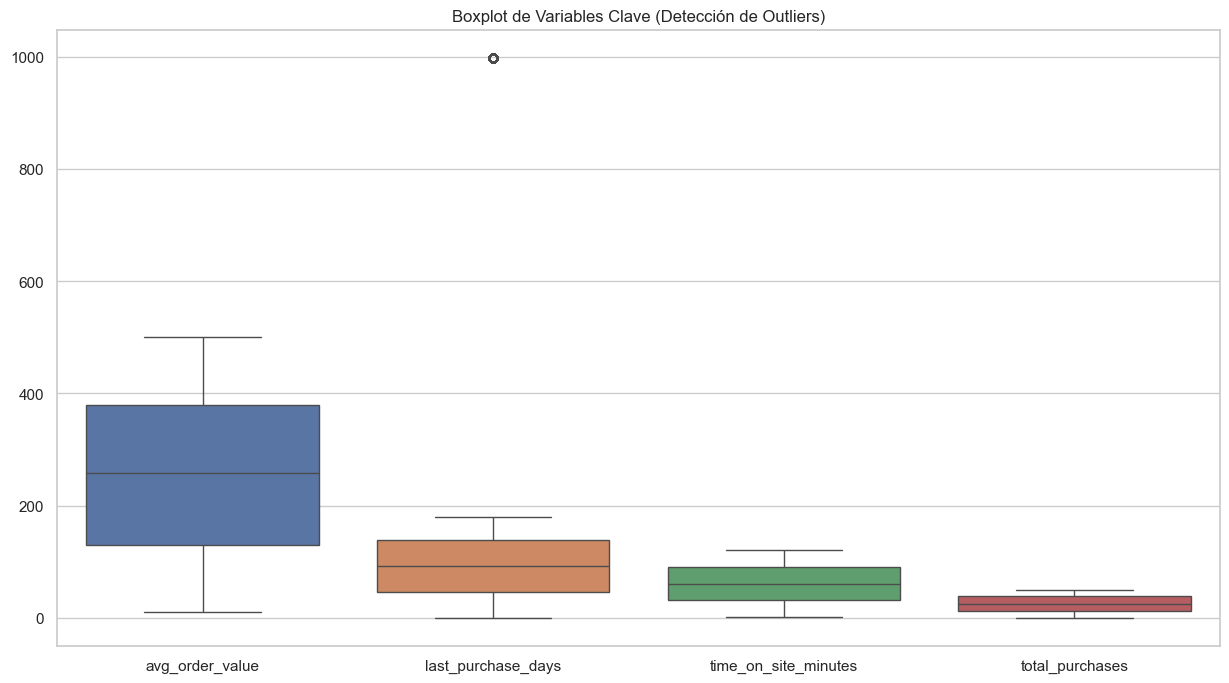

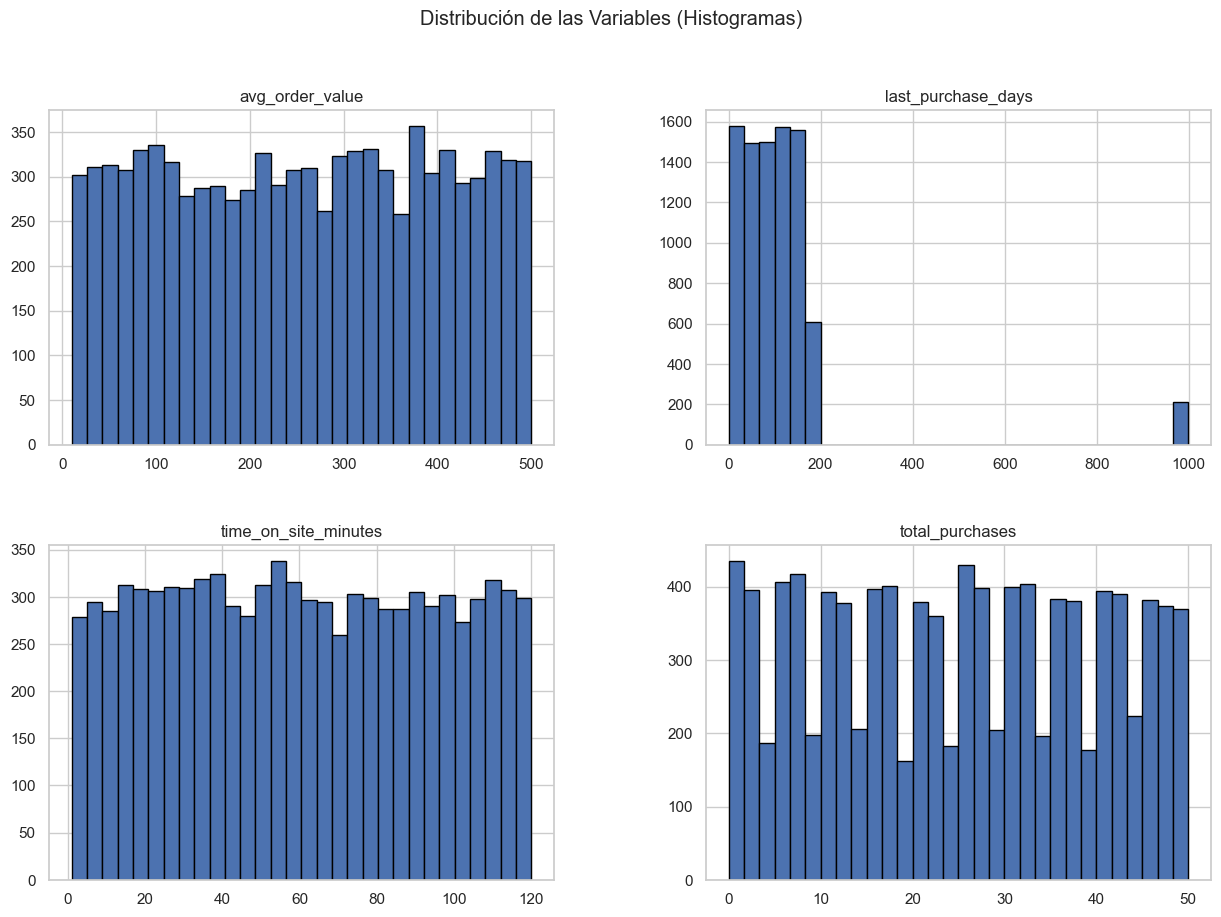

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuramos el estilo
sns.set_theme(style="whitegrid")

# 1. Gráfico de Boxplot 
plt.figure(figsize=(15, 8))

cols_interes = ['avg_order_value', 'last_purchase_days', 'time_on_site_minutes', 'total_purchases']
sns.boxplot(data=df[cols_interes])
plt.title("Boxplot de Variables Clave (Detección de Outliers)")
plt.show()

# 2. Gráfico de Histograma para ver la Distribución
df[cols_interes].hist(figsize=(15, 10), bins=30, edgecolor='black')
plt.suptitle("Distribución de las Variables (Histogramas)")
plt.show()

In [13]:
df.head (10)

,age_group,location,device_type,subscription_type,days_since_registration,total_purchases,avg_order_value,last_purchase_days,sessions_last_30_days,time_on_site_minutes,pages_per_session,cart_abandonment_rate,purchase_frequency,dar_promocion
0,18-25,Mendoza,Mobile,Free,38,6,341.58,139.0,2,71.3,NaN,0.075,4.74,1
1,26-35,Buenos Aires,Mobile,Basic,246,34,215.56,114.0,18,34.1,17.5,0.607,4.15,0
2,36-45,Buenos Aires,Mobile,Enterprise,284,21,60.08,97.0,3,43.7,7.5,0.212,2.22,1
3,36-45,Cordoba,Tablet,Free,343,35,153.66,160.0,19,106.4,7.9,0.154,3.06,0
4,18-25,Buenos Aires,Mobile,Free,330,14,434.58,97.0,8,55.0,16.8,0.130,1.27,1
5,18-25,Buenos Aires,Tablet,Basic,184,38,321.14,136.0,23,30.1,9.8,0.216,6.20,0
6,36-45,Buenos Aires,Mobile,Premium,38,3,122.23,NaN,25,38.5,6.1,0.169,2.37,1
7,46-55,Buenos Aires,Desktop,Free,75,41,234.84,67.0,4,30.3,11.7,0.210,16.40,1
8,26-35,Rosario,Mobile,Enterprise,66,8,259.67,23.0,24,6.6,3.1,0.502,3.64,1
9,26-35,Buenos Aires,Mobile,Enterprise,17,33,133.19,141.0,27,113.1,13.9,0.092,33.00,0


## 2) Feature engineering (crear más features)

Feature engineering = crear variables nuevas a partir de variables existentes.

- Puede mejorar la señal del modelo (resumir patrones útiles).
- Riesgo: **data leakage** si una feature usa información que no estaría disponible al momento de predecir en producción.

En este caso creamos features derivadas simples (tasas / diferencias) para practicar el flujo.

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.compose import ColumnTransformer
from category_encoders import BinaryEncoder

In [15]:
# 1. Valor total gastado por el cliente
df['total_spent'] = df['total_purchases'] * df['avg_order_value']

# 2. Páginas vistas por minuto (Engagement de velocidad)
df['pages_per_minute'] = df['pages_per_session'] / (df['time_on_site_minutes'] + 1)

# 3. Score de riesgo (Abandono combinado con inactividad)
df['risk_score'] = df['cart_abandonment_rate'] * df['last_purchase_days']

print("✅ Variables creadas: total_spent, pages_per_minute, risk_score")
df[['total_spent', 'pages_per_minute', 'risk_score']].head()

✅ Variables creadas: total_spent, pages_per_minute, risk_score


,total_spent,pages_per_minute,risk_score
0,2049.48,NaN,10.425
1,7329.04,0.498575,69.198
2,1261.68,0.167785,20.564
3,5378.10,0.073557,24.640
4,6084.12,0.300000,12.610


In [16]:
days = df['days_since_registration'].clip(lower=1)  # Evitar división por cero, dejar 1 si el valor es menor a 0

df['total_purchases_per_day'] = df['total_purchases'] / days

df["days_between_first_and_last_purchase"] = df["days_since_registration"] - df["last_purchase_days"]

df["bucket_avg_order_value"] = pd.cut(df["avg_order_value"], bins=3, labels=["low", "medium", "high"])

In [17]:
# 1. Creamos una lista con todas las columnas excepto la objetivo
cols = [c for c in df.columns if c != 'dar_promocion']

# 2. Reorganizamos el dataframe: todas las columnas + la objetivo al final
df = df[cols + ['dar_promocion']]

# 3. Verificamos con .info()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                                Non-Null Count  Dtype   
---  ------                                --------------  -----   
 0   age_group                             9507 non-null   str     
 1   location                              9702 non-null   str     
 2   device_type                           9819 non-null   str     
 3   subscription_type                     9894 non-null   str     
 4   days_since_registration               10000 non-null  int64   
 5   total_purchases                       10000 non-null  int64   
 6   avg_order_value                       9223 non-null   float64 
 7   last_purchase_days                    8526 non-null   float64 
 8   sessions_last_30_days                 10000 non-null  int64   
 9   time_on_site_minutes                  9001 non-null   float64 
 10  pages_per_session                     9046 non-null   float64 
 11  cart_abandonme

## 3) Split de datos (train/test)

Separaremos los datos para simular el escenario real:

- Entrenas con `train`.
- Evalúas con `test` (datos “nuevos” para el modelo).

`random_state` asegura reproducibilidad.

`X` = features (entradas) y `y` = target (lo que quieres predecir).

In [18]:
# train test split
from sklearn.model_selection import train_test_split

X = df.drop(columns=["dar_promocion"])
y = df["dar_promocion"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Verificamos el tamaño de los grupos
print(f"Entrenamiento: {X_train.shape[0]} registros")
print(f"Prueba: {X_test.shape[0]} registros")

Entrenamiento: 7000 registros
Prueba: 3000 registros


## 4) Preprocesamiento: numéricas vs categóricas (y por qué)

En este dataset tienes dos familias de features:

### Variables numéricas
Ejemplos: `avg_order_value`, `time_on_site_minutes`, `purchase_frequency`.

- **Imputación**: muchos modelos no aceptan `NaN`.
- **Escalado** (por ejemplo `StandardScaler`): en modelos lineales (Logistic Regression) ayuda porque hace comparables las magnitudes.

### Variables categóricas
Ejemplos: `age_group`, `location`, `device_type`, `subscription_type`.

- Deben convertirse a números. La opción clásica es **One-Hot Encoding**.
- `handle_unknown='ignore'`: si aparece una categoría nueva en producción, el pipeline no falla.

### Por qué `ColumnTransformer`
Permite aplicar transformaciones diferentes a subconjuntos de columnas (numéricas vs categóricas) en un solo objeto reproducible.

In [19]:
# 1. Identificar las familias de features (Columnas)
# Esto separa automáticamente los números de los textos
numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_train.select_dtypes(include=['object', 'category', 'str']).columns

In [20]:
# lista Numerica
print("--- Lista Numerica ---")
print(numeric_features)

print("\n--- lista Categorica ---")
print(categorical_features)

--- Lista Numerica ---
Index(['days_since_registration', 'total_purchases', 'avg_order_value',
       'last_purchase_days', 'sessions_last_30_days', 'time_on_site_minutes',
       'pages_per_session', 'cart_abandonment_rate', 'purchase_frequency',
       'total_spent', 'pages_per_minute', 'risk_score',
       'total_purchases_per_day', 'days_between_first_and_last_purchase'],
      dtype='str')

--- lista Categorica ---
Index(['age_group', 'location', 'device_type', 'subscription_type',
       'bucket_avg_order_value'],
      dtype='str')


In [22]:
# Tratamiento para las variables numéricas

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), 
    ('scaler', MinMaxScaler())                     
])

# Tratamiento para las variables categóricas 

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('binary', BinaryEncoder())                    
])

# Crear el ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

print("✅ ¡Ahora sí! Preprocesador configurado sin errores.")

✅ ¡Ahora sí! Preprocesador configurado sin errores.


## 5) Pipeline: preprocesamiento + modelo (evitar data leakage)

Usaremos:

- `Pipeline`: encapsula todos los pasos (imputación, escalado, one-hot, modelo).
- `ColumnTransformer`: separa numéricas/categóricas.

Punto clave: si haces imputación/one-hot *antes* del split o fuera del pipeline, podrías mezclar información del test en el entrenamiento (data leakage).

=== MÉTRICAS: RANDOM FOREST BASE ===
Accuracy:  0.4863
Precision: 0.4848
Recall:    0.4579
F1-Score:  0.4710
ROC-AUC:   0.4848


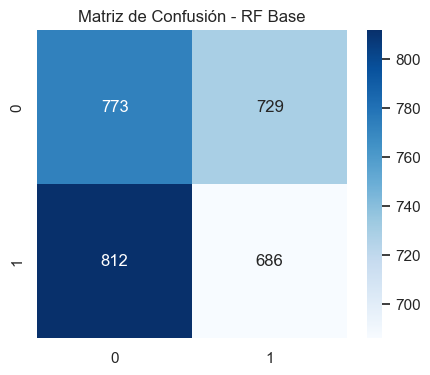

In [31]:
from sklearn.ensemble import RandomForestClassifier 
from category_encoders import BinaryEncoder    
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt     

# Listas automáticas incluyendo nuevas variables numeric_features y categorical_features

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), 
    ('scaler', MinMaxScaler()) 
])

# Pipeline Categórico 
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('binary', BinaryEncoder())
])

# Combinar en ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features),
    ],
    remainder="drop",
)

# 5. Pipeline completo con Random Forest 
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42)) 
])

# Entrenar (Ajustar)
pipeline.fit(X_train, y_train)

# Predicciones y métricas
y_pred_rf = pipeline.predict(X_test)
y_proba_rf = pipeline.predict_proba(X_test)[:, 1]

print("=== MÉTRICAS: RANDOM FOREST BASE ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba_rf):.4f}")

# Visualización de la Matriz
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión - RF Base')
plt.show()

## GridSearchCV

🔍 Buscando la mejor configuración... esto puede tardar unos segundos.

=== MÉTRICAS: RANDOM FOREST (GRIDSEARCH) ===
Mejores parámetros: {'classifier__max_depth': None, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 100}
Accuracy:  0.4863
Precision: 0.4848
Recall:    0.4579
F1-Score:  0.4710
ROC-AUC:   0.4848


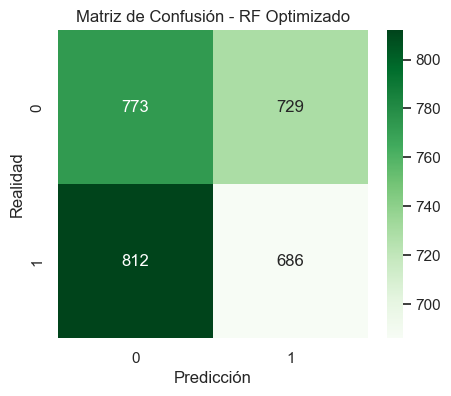

In [32]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'classifier__n_estimators': [50, 100], 
    'classifier__max_depth': [None, 5, 10], 
    'classifier__min_samples_split': [2, 5] 
}

# Creamos el buscador
grid_search = GridSearchCV(pipeline, param_grid, cv=3, scoring='roc_auc', n_jobs=-1)

print("🔍 Buscando la mejor configuración... esto puede tardar unos segundos.")
grid_search.fit(X_train, y_train)

# Extraemos el mejor modelo 
best_model = grid_search.best_estimator_

# Predicciones con el modelo optimizado
y_pred_grid = best_model.predict(X_test)
y_proba_grid = best_model.predict_proba(X_test)[:, 1]

# Metricas del modelo optimizado
print("\n" + "="*40)
print("=== MÉTRICAS: RANDOM FOREST (GRIDSEARCH) ===")
print(f"Mejores parámetros: {grid_search.best_params_}")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_grid):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_grid):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_grid):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_grid):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba_grid):.4f}")
print("="*40)

# Matriz de Confusión 
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_grid), annot=True, fmt='d', cmap='Greens')
plt.title('Matriz de Confusión - RF Optimizado')
plt.ylabel('Realidad')
plt.xlabel('Predicción')
plt.show()

## GradientBoostingClassifier 

🚀 === MÉTRICAS: GRADIENT BOOSTING ===
Accuracy:  0.4897
Precision: 0.4883
Recall:    0.4606
F1-Score:  0.4741
ROC-AUC:   0.4920


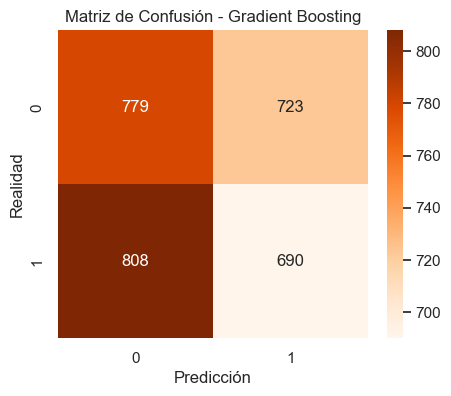

In [34]:
from sklearn.ensemble import GradientBoostingClassifier

# Pipeline usando Boosting
pipeline_boosting = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, random_state=42))
])

# 2. Entrenamos
pipeline_boosting.fit(X_train, y_train)

# 3. Evaluamos 
y_pred_boost = pipeline_boosting.predict(X_test)
y_proba_boost = pipeline_boosting.predict_proba(X_test)[:, 1]

# Calcular Métricas 
accuracy_boost = accuracy_score(y_test, y_pred_boost)
precision_boost = precision_score(y_test, y_pred_boost)
recall_boost = recall_score(y_test, y_pred_boost)
f1_boost = f1_score(y_test, y_pred_boost)
roc_boost = roc_auc_score(y_test, y_proba_boost)

# Mostrar Metricasprint("\n" + "="*40)
print("🚀 === MÉTRICAS: GRADIENT BOOSTING ===")
print(f"Accuracy:  {accuracy_boost:.4f}")
print(f"Precision: {precision_boost:.4f}")
print(f"Recall:    {recall_boost:.4f}")
print(f"F1-Score:  {f1_boost:.4f}")
print(f"ROC-AUC:   {roc_boost:.4f}")
print("="*40)

# 6. Matriz de Confusión
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_boost), annot=True, fmt='d', cmap='Oranges')
plt.title('Matriz de Confusión - Gradient Boosting')
plt.ylabel('Realidad')
plt.xlabel('Predicción')
plt.show()

## Comparacion de resultados

--- 📋 CUADRO COMPARATIVO DE RENDIMIENTO ---


,Modelo,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,RF Base,0.4863,0.4848,0.4579,0.4710,0.4848
1,RF GridSearch,0.4863,0.4848,0.4579,0.4710,0.4848
2,Gradient Boosting,0.4897,0.4883,0.4606,0.4741,0.4920


C:\Users\Usuario\AppData\Local\Temp\ipykernel_49500\1474581258.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


<Figure size 1500x1000 with 0 Axes>

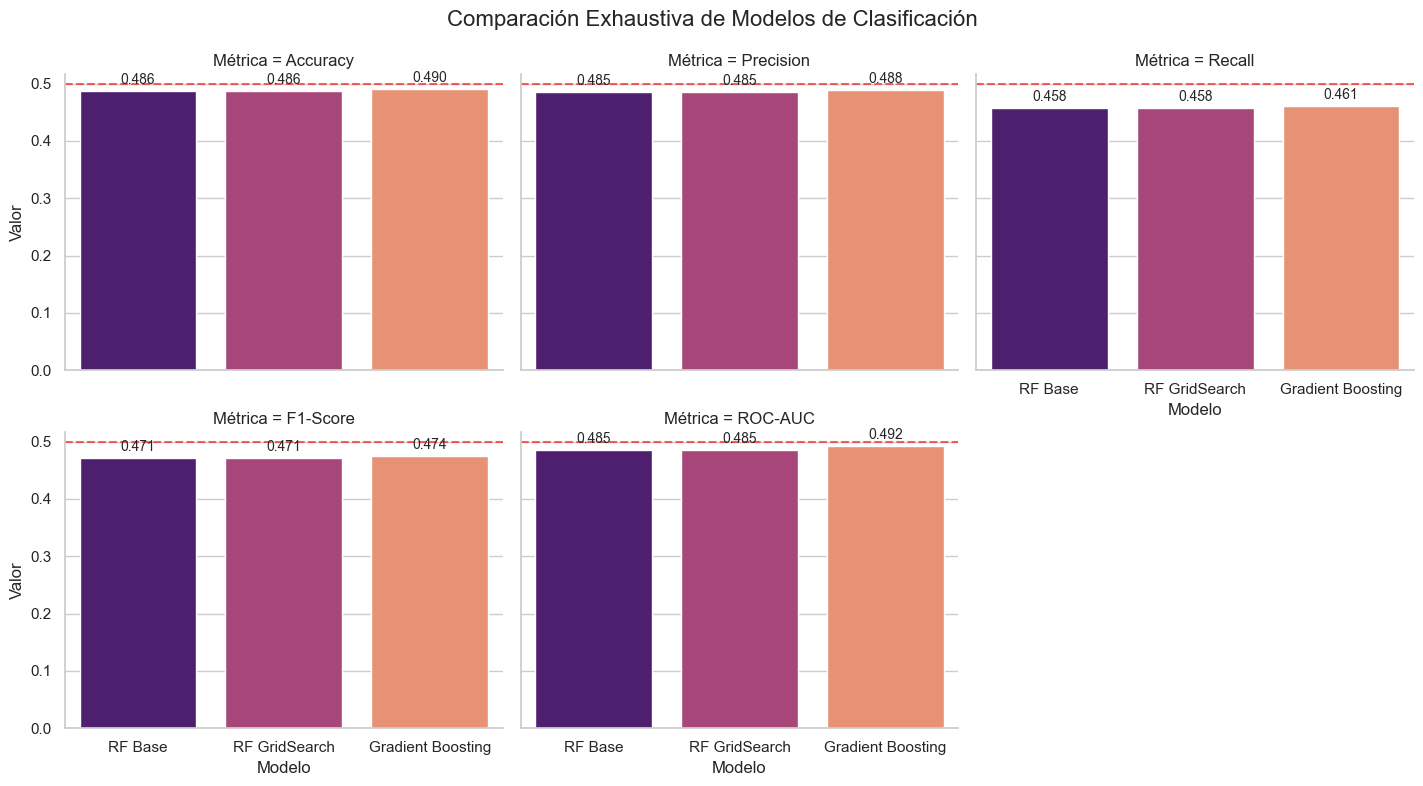

In [37]:
# 1. Recopilación de TODAS las métricas en una lista de diccionarios
datos_finales = [
    {
        'Modelo': 'RF Base',
        'Accuracy': accuracy_score(y_test, y_pred_rf),
        'Precision': precision_score(y_test, y_pred_rf),
        'Recall': recall_score(y_test, y_pred_rf),
        'F1-Score': f1_score(y_test, y_pred_rf),
        'ROC-AUC': roc_auc_score(y_test, y_proba_rf)
    },
    {
        'Modelo': 'RF GridSearch',
        'Accuracy': accuracy_score(y_test, y_pred_grid),
        'Precision': precision_score(y_test, y_pred_grid),
        'Recall': recall_score(y_test, y_pred_grid),
        'F1-Score': f1_score(y_test, y_pred_grid),
        'ROC-AUC': roc_auc_score(y_test, y_proba_grid)
    },
    {
        'Modelo': 'Gradient Boosting',
        'Accuracy': accuracy_score(y_test, y_pred_boost),
        'Precision': precision_score(y_test, y_pred_boost),
        'Recall': recall_score(y_test, y_pred_boost),
        'F1-Score': f1_score(y_test, y_pred_boost),
        'ROC-AUC': roc_auc_score(y_test, y_proba_boost)
    }
]

# 2. Crear DataFrame para la Tabla y Gráficas
df_resultados = pd.DataFrame(datos_finales)

# 3. Mostrar la Tabla Comparativa Recomendada
print("--- 📋 CUADRO COMPARATIVO DE RENDIMIENTO ---")
display(df_resultados.round(4)) # Usamos display para que se vea más bonito en Jupyter/Colab

# 4. Reestructurar datos para graficar fácilmente (Melt)
df_plot = df_resultados.melt(id_vars='Modelo', var_name='Métrica', value_name='Valor')

# 5. Generar la Gran Gráfica Comparativa (Multi-Panel)
plt.figure(figsize=(15, 10))
sns.set_style("whitegrid")

# Creamos una gráfica de barras por cada métrica
g = sns.catplot(
    data=df_plot, kind="bar",
    x="Modelo", y="Valor", col="Métrica",
    palette="magma", col_wrap=3, height=4, aspect=1.2
)

# Añadir etiquetas de valor en cada barra y línea de umbral
for ax in g.axes.flat:
    ax.axhline(0.5, color='red', linestyle='--', alpha=0.6, label='Umbral 0.5')
    for p in ax.patches:
        ax.annotate(format(p.get_height(), '.3f'), 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha = 'center', va = 'center', 
                    xytext = (0, 8), 
                    textcoords = 'offset points', fontsize=10)

plt.subplots_adjust(top=0.9)
g.fig.suptitle('Comparación Exhaustiva de Modelos de Clasificación', fontsize=16)
plt.show()

### (Opcional) Ver cuántas features quedan después del preprocesamiento

`OneHotEncoder` puede expandir bastante el número de columnas. Esto es normal. Aquí solo inspeccionamos:

- cuántas columnas finales existen
- algunos nombres generados

Esto es útil para debugging e interpretabilidad (aun si luego no interpretas coeficientes).

In [41]:
try:
    feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()
    print("Nº de features después del preprocesamiento:", len(feature_names))
    pd.Series(feature_names).head(20)
except Exception as e:
    print("No se pudieron obtener los nombres de features:", e)

Nº de features después del preprocesamiento: 29


In [42]:
feature_names

array(['num__days_since_registration', 'num__total_purchases',
       'num__avg_order_value', 'num__last_purchase_days',
       'num__sessions_last_30_days', 'num__time_on_site_minutes',
       'num__pages_per_session', 'num__cart_abandonment_rate',
       'num__purchase_frequency', 'num__total_spent',
       'num__pages_per_minute', 'num__risk_score',
       'num__total_purchases_per_day',
       'num__days_between_first_and_last_purchase', 'cat__0_0',
       'cat__0_1', 'cat__0_2', 'cat__1_0', 'cat__1_1', 'cat__1_2',
       'cat__2_0', 'cat__2_1', 'cat__2_2', 'cat__3_0', 'cat__3_1',
       'cat__3_2', 'cat__4_0', 'cat__4_1', 'cat__4_2'], dtype=object)

In [43]:
# Predicciones
# - y_pred: clase predicha usando el umbral por defecto (0.5)
# - y_pred_proba: probabilidad estimada de la clase positiva (y=1)

y_pred = pipeline.predict(X_test)
y_pred_proba = pipeline.predict_proba(X_test)[:, 1]

In [44]:
y_pred_proba

array([0.48, 0.46, 0.46, ..., 0.56, 0.5 , 0.4 ], shape=(3000,))

## 6) Métricas de clasificación: cómo leer el reporte

`classification_report` muestra, por clase:

- **precision**: de lo que el modelo predijo como positivo, ¿cuánto fue correcto?
- **recall**: de los positivos reales, ¿cuántos detectó?
- **f1-score**: balance entre precision y recall (útil cuando quieres un trade-off).
- **support**: cuántos ejemplos hay de cada clase.

Promedios:

- **macro avg**: promedio simple entre clases (cada clase pesa igual). Útil si quieres tratar todas las clases con la misma importancia.
- **weighted avg**: promedio ponderado por `support` (la clase más frecuente pesa más). Útil cuando el dataset está desbalanceado.

En binaria, macro vs weighted suelen ser parecidos si no hay mucho desbalance; si hay desbalance fuerte, pueden diferir bastante.

### Matriz de confusión (TP/FP/FN/TN)

La matriz de confusión te permite conectar el reporte con conteos concretos:

- **TP (True Positives)**: predijo 1 y era 1.
- **FP (False Positives)**: predijo 1 y era 0.
- **FN (False Negatives)**: predijo 0 y era 1.
- **TN (True Negatives)**: predijo 0 y era 0.

Intuición:

- Subir **precision** suele implicar bajar **recall** (y viceversa).
- En escenarios desbalanceados, `accuracy` puede verse “bien” incluso con un modelo mediocre.

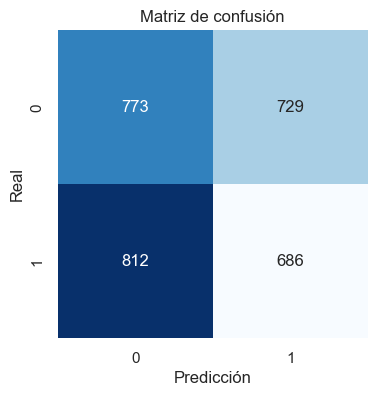

In [45]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(4, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Matriz de confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

## 7) Umbral (threshold) y trade-off precision/recall

En clasificación binaria, `predict()` usa un umbral por defecto (típicamente 0.5):

- Si `P(y=1) >= 0.5` entonces predice 1.
- Si no, predice 0.

Cambiar el umbral cambia el equilibrio:

- Umbral **más bajo** (ej. 0.3): más positivos predichos → suele subir `recall` y bajar `precision`.

¿Explicación?
- Voy a aumentar mis positivos pero realmente pocos son buenos. … tendremos más falsos positivos y pocos verdaderos positivos. 
- Aumentan los TP, pero aumentan todavía más los FP (por eso la precisión baja).

---------
- Umbral **más alto** (ej. 0.7): menos positivos predichos → suele subir `precision` y bajar `recall`.

¿Explicación?
- Si subimos el umbral, nos volvemos más estrictos y solo marcamos como positivo a los casos con probabilidad muy alta. Eso reduce los falsos positivos (FP), así que la precision sube, pero aumenta los falsos negativos (FN) (positivos reales que ya no alcanzan el umbral), por lo que el recall baja

Esto es clave en negocio:

- Si el costo de **no dar promoción a alguien que sí la necesitaba** es alto → priorizas `recall`.
- Si el costo de **dar promoción innecesaria** es alto → priorizas `precision`.

In [46]:
from sklearn.metrics import classification_report

for thr in [0.3, 0.5, 0.7]:
    y_pred_thr = (y_pred_proba >= thr).astype(int)
    print(f"\n--- Threshold = {thr} ---")
    print(classification_report(y_test, y_pred_thr))


--- Threshold = 0.3 ---
              precision    recall  f1-score   support

           0       0.56      0.00      0.01      1502
           1       0.50      1.00      0.67      1498

    accuracy                           0.50      3000
   macro avg       0.53      0.50      0.34      3000
weighted avg       0.53      0.50      0.34      3000


--- Threshold = 0.5 ---
              precision    recall  f1-score   support

           0       0.48      0.46      0.47      1502
           1       0.48      0.51      0.49      1498

    accuracy                           0.48      3000
   macro avg       0.48      0.48      0.48      3000
weighted avg       0.48      0.48      0.48      3000


--- Threshold = 0.7 ---
              precision    recall  f1-score   support

           0       0.50      0.99      0.67      1502
           1       0.57      0.01      0.02      1498

    accuracy                           0.50      3000
   macro avg       0.53      0.50      0.34      3000

In [47]:
# Evaluate
from sklearn.metrics import classification_report, roc_auc_score

print("ROC-AUC Score:", roc_auc_score(y_test, y_pred_proba))
print("\nClassification Report (threshold=0.5):")
print(classification_report(y_test, y_pred))

ROC-AUC Score: 0.484792417408742

Classification Report (threshold=0.5):
              precision    recall  f1-score   support

           0       0.49      0.51      0.50      1502
           1       0.48      0.46      0.47      1498

    accuracy                           0.49      3000
   macro avg       0.49      0.49      0.49      3000
weighted avg       0.49      0.49      0.49      3000



## **Actividad**

Prueba:

1. Imputar los numericos con otras estrategias
2. Crea nuevas features
3. Usar BinaryEncoder para las categoricas
4. Usar MinMaxScaler para las numericas
5. Usar RandomForestClassifier para el modelo
6. Usar GridSearchCV para encontrar los mejores hiperparametros
7. Juega con el split de datos


Subir a repositorio invividual con la solución. 